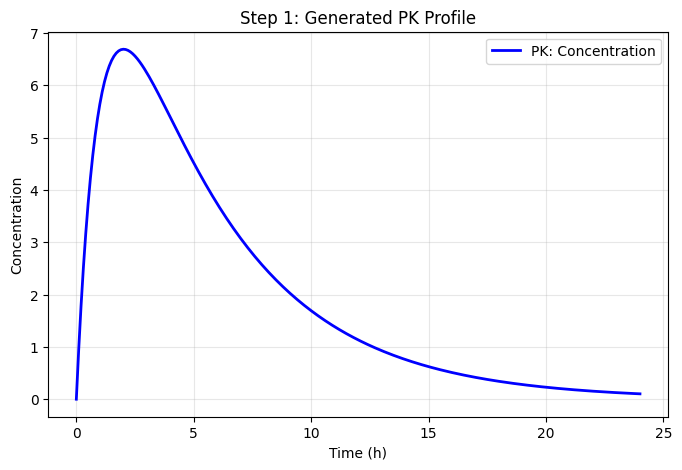

C_max (峰值浓度): 6.6873


In [1]:
# ============================
# 1. 生成一房室 PK 数据 (One-Compartment Model)
# ============================

import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子以保证结果可复现
np.random.seed(42)

# 参数设定
D = 100.0       # 剂量 (Dose)
V = 10.0        # 分布容积 (Volume)
ka = 1.0        # 吸收速率常数 (1/h)
ke = 0.2        # 消除速率常数 (1/h)
F = 1.0         # 生物利用度

# 定义时间向量 (0 到 24小时, 241个点)
t = np.linspace(0, 24, 241)

# 计算血药浓度 C(t) - Bateman 公式
# C(t) = (F*D*ka / (V*(ka-ke))) * (exp(-ke*t) - exp(-ka*t))
pre_factor = (F * D * ka) / (V * (ka - ke))
C_t = pre_factor * (np.exp(-ke * t) - np.exp(-ka * t))

# 可视化检查
plt.figure(figsize=(8, 5))
plt.plot(t, C_t, 'b-', linewidth=2, label='PK: Concentration')
plt.title('Step 1: Generated PK Profile')
plt.xlabel('Time (h)')
plt.ylabel('Concentration')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 打印峰值信息
print(f"C_max (峰值浓度): {np.max(C_t):.4f}")

正在模拟 20 位受试者...


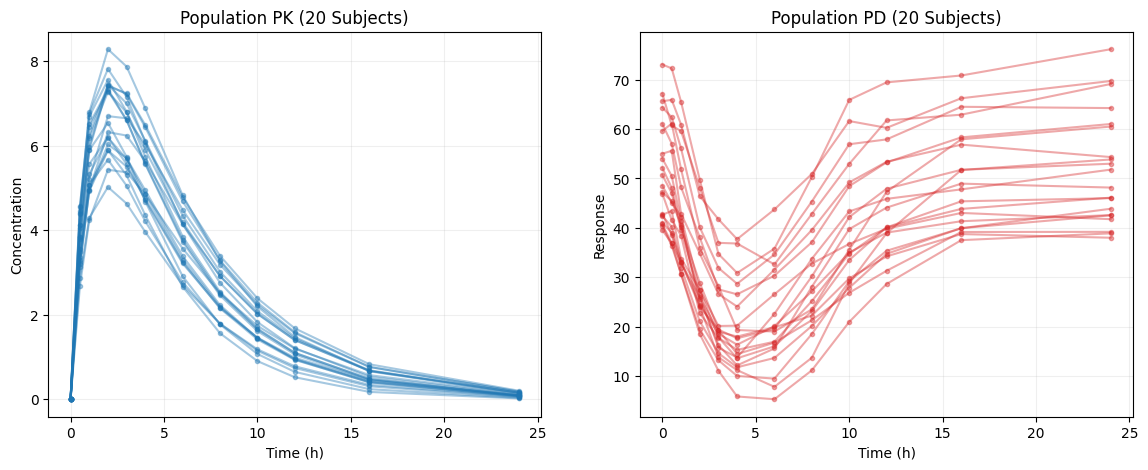

总样本量: 240 (20人 x 12点)
数据列: Time | Concentration | Response


In [2]:
# ============================
# 2. 生成群体 PK/PD 数据 (Population PK/PD)
# ============================

from scipy.integrate import odeint
from scipy.interpolate import interp1d

# 受试者人数 & 稀疏采样点
n_subjects = 20
t_clinical = np.array([0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 24.0])

# 统一参数字典（PK + PD）
tv_params = {
    'D': 100.0, 'V': 10.0, 'ka': 1.0, 'ke': 0.2,     # PK
    'kin': 25.0, 'kout': 0.5, 'imax': 1.0, 'ec50': 4.0, 'gamma': 3.0  # PD
}

# 个体变异 (IIV) 系数
iiv_std = 0.15

# PD ODE（多级嵌套结构）
def pd_ode(R, t, kin, kout, imax, ec50, gamma, C_func):
    c = max(C_func(t), 0.0)
    hill = (c**gamma) / (ec50**gamma + c**gamma)
    return kin - (kin * imax) * hill - kout * R

all_data_list = []

# 可视化准备
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
print(f"正在模拟 {n_subjects} 位受试者...")

for i in range(n_subjects):
    # 1) 个体参数 (log-normal IIV)
    p = {k: v * np.exp(np.random.normal(0, iiv_std)) for k, v in tv_params.items()}

    # PK 参数一般更稳定，这里固定剂量
    p['D'] = tv_params['D']

    # 2) 个体 PK 曲线 (Bateman)
    pre = (p['D'] * p['ka']) / (p['V'] * (p['ka'] - p['ke']))
    C_dense = pre * (np.exp(-p['ke'] * t) - np.exp(-p['ka'] * t))
    C_interp = interp1d(t, C_dense, kind='cubic', fill_value="extrapolate")

    # 3) PD 动力学
    R0 = p["kin"] / p["kout"]
    R_dense = odeint(pd_ode, R0, t, args=(p["kin"], p["kout"], p["imax"], p["ec50"], p["gamma"], C_interp)).flatten()

    # 4) 临床采样 + 噪声
    C_obs = C_interp(t_clinical)
    R_true_loc = interp1d(t, R_dense)(t_clinical)
    R_obs = R_true_loc + np.random.normal(0, 0.03 * np.mean(R_dense), size=len(t_clinical))

    subj_data = np.column_stack((t_clinical, C_obs, R_obs))
    all_data_list.append(subj_data)

    # 绘图
    ax1.plot(t_clinical, C_obs, '.-', alpha=0.4, color='tab:blue')
    ax2.plot(t_clinical, R_obs, '.-', alpha=0.4, color='tab:red')

# 汇总为最终数据集
pop_data = np.vstack(all_data_list)

ax1.set_title(f'Population PK ({n_subjects} Subjects)')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Concentration')
ax1.grid(True, alpha=0.2)

ax2.set_title(f'Population PD ({n_subjects} Subjects)')
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('Response')
ax2.grid(True, alpha=0.2)

plt.show()

print(f"总样本量: {pop_data.shape[0]} (20人 x 12点)")
print(f"数据列: Time | Concentration | Response")

D:\PycharmProjects\DeePyMoD\src\deepymod\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Running on cuda
Preprocessing data
Dataset is using device:  cuda
Batch 0 Input (Time) shape: torch.Size([192, 1])
Batch 0 Target (R, C) shape: torch.Size([192, 2])


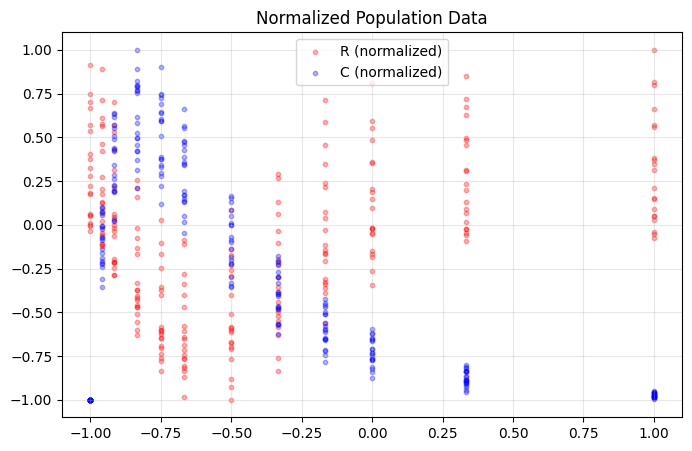

In [3]:
# ============================
# 3. Dataset 构建 + 归一化 + 划分
# ============================
import torch
import torch.nn as nn
from deepymod.data import Dataset, get_train_test_loader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on {device}")

def load_population_data():
    # 输入：Time [N, 1]
    t_tensor = torch.tensor(pop_data[:, 0:1], dtype=torch.float32)
    # 输出：[R, C] -> 注意顺序是 [Response, Concentration]
    y_tensor = torch.tensor(pop_data[:, [2, 1]], dtype=torch.float32)
    return t_tensor, y_tensor

# Dataset
dataset = Dataset(
    load_population_data,
    preprocess_kwargs={
        "noise_level": 0.0,
        "normalize_coords": True,   # 时间归一化到 [-1,1]
        "normalize_data": True,     # R/C 归一化到 [-1,1]
    },
    device=device
)

# 划分训练/测试
train_dataloader, test_dataloader = get_train_test_loader(dataset, train_test_split=0.8)

# 快速检查一个 batch
for batch_idx, (input_batch, target_batch) in enumerate(train_dataloader):
    if batch_idx == 0:
        print(f"Batch 0 Input (Time) shape: {input_batch.shape}")
        print(f"Batch 0 Target (R, C) shape: {target_batch.shape}")
        break

# 可视化归一化后的数据
t_norm = dataset.get_coords().cpu().numpy()
y_norm = dataset.get_data().cpu().numpy()

plt.figure(figsize=(8, 5))
plt.scatter(t_norm, y_norm[:, 0], s=10, c='r', alpha=0.3, label='R (normalized)')
plt.scatter(t_norm, y_norm[:, 1], s=10, c='b', alpha=0.3, label='C (normalized)')
plt.title('Normalized Population Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:
# ============================
# 4. Operator Bank
# ============================

from typing import List, Tuple
from deepymod import Library
from torch.autograd import grad
import torch.nn.functional as tnf  # ✅ 避免与生物利用度 F 冲突

TensorList = List[torch.Tensor]

class OperatorBank(Library):
    def __init__(
        self,
        max_depth=2,
        include_products=True,
        max_terms=96,
        allow_ops=("linear", "sat", "hill", "pow", "inh", "sqrt", "log", "exp"),
        allow_nested=("sat", "hill", "pow", "inh"),
        forbid_patterns=("inh(1", "log(1", "sqrt(1"),
    ):
        super().__init__()
        self.max_depth = max_depth
        self.include_products = include_products
        self.max_terms = max_terms
        self.allow_ops = allow_ops
        self.allow_nested = allow_nested
        self.forbid_patterns = forbid_patterns

        # 可学习参数
        self.k_sat_R = nn.Parameter(torch.tensor(0.0))
        self.k_sat_C = nn.Parameter(torch.tensor(0.0))

        self.ec50_R = nn.Parameter(torch.tensor(0.0))
        self.ec50_C = nn.Parameter(torch.tensor(0.0))

        self.gamma_R = nn.Parameter(torch.tensor(1.0))
        self.gamma_C = nn.Parameter(torch.tensor(1.0))

        self.pow_R = nn.Parameter(torch.tensor(1.0))
        self.pow_C = nn.Parameter(torch.tensor(1.0))

        self.exp_R = nn.Parameter(torch.tensor(0.1))
        self.exp_C = nn.Parameter(torch.tensor(0.1))

        self.term_names = []

    # ---- 原子元 ----
    def linear(self, x): return x

    def saturate(self, x, k):
        k_pos = tnf.softplus(k)
        return x / (k_pos + x + 1e-6)

    def hill(self, x, ec50, gamma):
        ec50_pos = tnf.softplus(ec50)
        gamma_pos = tnf.softplus(gamma)
        x_safe = torch.relu(x) + 1e-6
        return (x_safe**gamma_pos) / (ec50_pos**gamma_pos + x_safe**gamma_pos)

    def power(self, x, p):
        p_pos = tnf.softplus(p)
        return torch.pow(torch.relu(x) + 1e-6, p_pos)

    def inhibit(self, x):
        return 1.0 - x

    def sqrt(self, x):
        return torch.sqrt(torch.relu(x) + 1e-6)

    def log1p(self, x):
        return torch.log1p(torch.relu(x) + 1e-6)

    def expdecay(self, x, k):
        k_pos = tnf.softplus(k)
        return torch.exp(-k_pos * torch.relu(x))

    # ---- 结构先验过滤 ----
    def _is_valid_name(self, name):
        for pat in self.forbid_patterns:
            if pat in name:
                return False
        return True

    def _maybe_add(self, terms, names, value, name):
        if self._is_valid_name(name):
            terms.append(value)
            names.append(name)

    def build_terms(self, R, C):
        terms, names = [], []

        # 基础项
        one = torch.ones_like(R)
        base = [(one, "1"), (R, "R"), (C, "C")]
        for t, n in base:
            self._maybe_add(terms, names, t, n)

        # depth=1 原子
        atoms = []
        if "sat" in self.allow_ops:
            atoms += [(self.saturate(R, self.k_sat_R), "sat(R)")]
            atoms += [(self.saturate(C, self.k_sat_C), "sat(C)")]
        if "hill" in self.allow_ops:
            atoms += [(self.hill(R, self.ec50_R, self.gamma_R), "hill(R)")]
            atoms += [(self.hill(C, self.ec50_C, self.gamma_C), "hill(C)")]
        if "pow" in self.allow_ops:
            atoms += [(self.power(R, self.pow_R), "pow(R)")]
            atoms += [(self.power(C, self.pow_C), "pow(C)")]
        if "inh" in self.allow_ops:
            atoms += [(self.inhibit(R), "inh(R)")]
            atoms += [(self.inhibit(C), "inh(C)")]
        if "sqrt" in self.allow_ops:
            atoms += [(self.sqrt(R), "sqrt(R)")]
            atoms += [(self.sqrt(C), "sqrt(C)")]
        if "log" in self.allow_ops:
            atoms += [(self.log1p(R), "log(R)")]
            atoms += [(self.log1p(C), "log(C)")]
        if "exp" in self.allow_ops:
            atoms += [(self.expdecay(R, self.exp_R), "exp(R)")]
            atoms += [(self.expdecay(C, self.exp_C), "exp(C)")]

        for t, n in atoms:
            self._maybe_add(terms, names, t, n)

        # depth=2 组合（结构先验限制）
        if self.max_depth >= 2:
            composed = []
            for t, n in atoms:
                if "sat" in self.allow_nested:
                    composed.append((self.saturate(t, self.k_sat_C), f"sat({n})"))
                if "hill" in self.allow_nested:
                    composed.append((self.hill(t, self.ec50_C, self.gamma_C), f"hill({n})"))
                if "pow" in self.allow_nested:
                    composed.append((self.power(t, self.pow_C), f"pow({n})"))
                if "inh" in self.allow_nested:
                    composed.append((self.inhibit(t), f"inh({n})"))
            for t, n in composed:
                self._maybe_add(terms, names, t, n)

        # 乘积项
        if self.include_products:
            prod = []
            max_prod = min(len(terms), 10)
            for i in range(max_prod):
                for j in range(i + 1, max_prod):
                    prod.append((terms[i] * terms[j], f"({names[i]}*{names[j]})"))
            for t, n in prod:
                self._maybe_add(terms, names, t, n)

        # 限制项数
        if len(terms) > self.max_terms:
            terms = terms[:self.max_terms]
            names = names[:self.max_terms]

        self.term_names = names
        theta = torch.cat(terms, dim=1)
        return theta

    def library(self, input: Tuple[torch.Tensor, torch.Tensor]) -> Tuple[TensorList, TensorList]:
        prediction, data = input
        R = prediction[:, 0:1]
        C = data[:, 1:2]  # C 来自已知输入

        # time derivative (只对 R 求导)
        dy = grad(
            prediction[:, 0],
            data,
            grad_outputs=torch.ones_like(prediction[:, 0]),
            create_graph=True
        )[0]
        time_deriv_list = [dy[:, 0:1]]

        theta = self.build_terms(R, C)
        return time_deriv_list, [theta]

# ---- 两阶段识别配置 ----
stage1_config = dict(
    max_depth=2,
    include_products=True,
    max_terms=96,
    allow_ops=("linear", "sat", "hill", "pow", "inh", "sqrt", "log", "exp"),
    allow_nested=("sat", "hill", "pow", "inh"),
)

stage2_config = dict(
    max_depth=1,
    include_products=False,
    max_terms=32,
    allow_ops=("linear", "hill", "sat", "pow", "inh"),
    allow_nested=("hill", "sat"),
)

In [10]:
# ============================
# 5. Stage-1：大库训练 + 多次投票（软引导版）
# ============================

from deepymod import DeepMoD
from deepymod.model.func_approx import NN
from deepymod.model.constraint import Constraint
from deepymod.model.sparse_estimators import Threshold
from deepymod.training import train
from deepymod.training.sparsity_scheduler import TrainTestPeriodic
from collections import Counter
import numpy as np

# ---- 稳健最小二乘（完全避免 solve 奇异）----
class LeastSquaresRidge(Constraint):
    def fit(self, sparse_thetas, time_derivs):
        coeff_vectors = []
        for theta, dt in zip(sparse_thetas, time_derivs):
            if theta.numel() == 0:
                coeff_vectors.append(torch.zeros((0, 1), device=theta.device))
                continue

            col_norm = torch.norm(theta, dim=0)
            keep = col_norm > 1e-8
            if torch.sum(keep) == 0:
                coeff_vectors.append(torch.zeros((theta.shape[1], 1), device=theta.device))
                continue

            theta_r = theta[:, keep]
            coeff_r = torch.pinverse(theta_r) @ dt

            coeff_full = torch.zeros((theta.shape[1], 1), device=theta.device)
            coeff_full[keep] = coeff_r
            coeff_vectors.append(coeff_full)

        return coeff_vectors

# ---- 稳健稀疏估计器：Ridge + Threshold ----
class RidgeThreshold(Threshold):
    def forward(self, thetas, time_derivs):
        eps = 1e-12
        normed_time_derivs = [
            (time_deriv / (torch.norm(time_deriv) + eps)).detach().cpu().numpy()
            for time_deriv in time_derivs
        ]
        normed_thetas = [
            (theta / (torch.norm(theta, dim=0, keepdim=True) + eps)).detach().cpu().numpy()
            for theta in thetas
        ]
        normed_thetas = [np.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0) for t in normed_thetas]
        normed_time_derivs = [np.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0) for t in normed_time_derivs]

        self.coeff_vectors = [
            self.fit(theta, time_deriv.squeeze())[:, None]
            for theta, time_deriv in zip(normed_thetas, normed_time_derivs)
        ]
        sparsity_masks = [
            torch.tensor(coeff_vector != 0.0, dtype=torch.bool)
            .squeeze()
            .to(thetas[0].device)
            for coeff_vector in self.coeff_vectors
        ]
        return sparsity_masks

    def fit(self, X, y):
        col_norm = np.linalg.norm(X, axis=0)
        keep = col_norm > 1e-8

        coeff_full = np.zeros(X.shape[1])
        if np.sum(keep) == 0:
            return coeff_full

        Xr = X[:, keep]
        lam = 1e-2
        XtX = Xr.T @ Xr + lam * np.eye(Xr.shape[1])
        Xty = Xr.T @ y
        coeff_r = np.linalg.solve(XtX, Xty)

        coeff_r[np.abs(coeff_r) < self.threshold] = 0.0
        coeff_full[keep] = coeff_r
        return coeff_full

# ---- Dataset：输入 [t, C]，输出 [R] ----
def load_pd_data():
    coords = torch.tensor(pop_data[:, [0, 1]], dtype=torch.float32)
    data = torch.tensor(pop_data[:, [2]], dtype=torch.float32)
    return coords, data

dataset_pd = Dataset(
    load_pd_data,
    preprocess_kwargs={
        "noise_level": 0.0,
        "normalize_coords": True,
        "normalize_data": True,
    },
    device=device
)

train_dataloader_pd, test_dataloader_pd = get_train_test_loader(dataset_pd, train_test_split=0.8)

# ---- Stage-1 库配置：禁嵌套 ----
stage1_config = dict(
    max_depth=1,
    include_products=True,
    max_terms=96,
    allow_ops=("linear", "sat", "hill", "pow", "inh", "sqrt", "log", "exp"),
    allow_nested=(),   # ✅ 禁掉嵌套
)

# ---- Stage-1 多次投票 ----
def run_stage1(seed, threshold=0.03):
    torch.manual_seed(seed)
    np.random.seed(seed)

    network = NN(2, [64, 64, 64, 64], 1)
    library = OperatorBank(**stage1_config)
    estimator = RidgeThreshold(threshold)
    constraint = LeastSquaresRidge()

    model = DeepMoD(network, library, estimator, constraint).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
    sparsity_scheduler = TrainTestPeriodic(periodicity=50, patience=200, delta=1e-6)

    train(
        model,
        train_dataloader_pd,
        test_dataloader_pd,
        optimizer,
        sparsity_scheduler,
        exp_ID=f"stage1_pd_seed{seed}",
        log_dir="runs/pd_stage1_vote",
        split=0.8,
        max_iterations=6000,
        write_iterations=100,
        delta=1e-4,
        patience=200,
    )

    mask = model.constraint.sparsity_masks[0].detach().cpu().numpy()
    coeffs = model.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()

    active = []
    for idx, (is_active, coeff) in enumerate(zip(mask, coeffs)):
        if idx >= len(model.library.term_names):
            break
        if is_active:
            active.append(model.library.term_names[idx])
    return active

# 多次投票
seeds = [0, 1, 2, 3, 4]
all_terms = []
for s in seeds:
    all_terms += run_stage1(s, threshold=0.03)

counts = Counter(all_terms)

# ---- 软引导评分（通用版）----
always_keep = {"1", "C"}  # 常数项 + 线性 C
prefer_terms = {"hill(C)", "sat(C)", "pow(C)", "inh(C)"}  # C-only 非线性
penalize_terms = {"sat(R)", "hill(R)", "pow(R)", "inh(R)", "log(R)", "sqrt(R)", "exp(R)"}

def score_term(t):
    score = counts.get(t, 0)
    if t in always_keep:
        score += 5
    if t in prefer_terms:
        score += 3
    if t in penalize_terms:
        score -= 3
    if "*" in t:
        score -= 2
    return score

sorted_terms = sorted(counts.keys(), key=lambda t: score_term(t), reverse=True)

# 至少保留 1 个 C-only 非线性项
c_only_candidates = [t for t in sorted_terms if "C" in t and "R" not in t]

stage1_active_terms = []
stage1_active_terms += list(always_keep)

if c_only_candidates:
    stage1_active_terms.append(c_only_candidates[0])

# 再补充前 N 个高分项
N = 8
for t in sorted_terms:
    if len(stage1_active_terms) >= N:
        break
    if t not in stage1_active_terms:
        stage1_active_terms.append(t)

# ---- 强制兜底：保证 C-only 非线性存在 ----
force_c_terms = ["hill(C)", "sat(C)", "pow(C)", "inh(C)"]
for t in force_c_terms:
    if t not in stage1_active_terms:
        stage1_active_terms.append(t)

print("\n[Stage-1 Voted Active Terms (Soft-Guided)]")
for t in stage1_active_terms:
    print("  ", t)

# 去重（保持顺序）
stage1_active_terms = list(dict.fromkeys(stage1_active_terms))

Preprocessing data
Dataset is using device:  cuda
   900  MSE: 2.05e-01  Reg: 1.26e+02  L1: 3.11e+07 Algorithm converged. Writing model to disk.
   500  MSE: 1.80e-01  Reg: 4.72e+06  L1: 4.97e+11 Algorithm converged. Writing model to disk.
   500  MSE: 1.83e-01  Reg: 1.80e+03  L1: 5.65e+07 Algorithm converged. Writing model to disk.
   600  MSE: 1.66e-01  Reg: 6.13e-01  L1: 6.46e+05 Algorithm converged. Writing model to disk.
   600  MSE: 2.59e-01  Reg: 7.31e+03  L1: 9.98e+08 Algorithm converged. Writing model to disk.

[Stage-1 Voted Active Terms (Soft-Guided)]
   1
   C
   C
   inh(C)
   R
   exp(C)
   sat(C)
   (1*R)
   hill(C)
   pow(C)


In [11]:
# ============================
# 6. Stage-2：软引导版（稳定 + 通用）
# ============================
# ---- 只保留 1 个 C-only 非线性（避免共线爆炸）----
c_only_pool = ["hill(C)", "sat(C)", "pow(C)", "inh(C)", "exp(C)", "log(C)", "sqrt(C)"]
preferred = ["hill(C)", "sat(C)", "pow(C)", "inh(C)"]

# 优先从偏好项选一个
selected_c = None
for t in preferred:
    if t in stage1_active_terms:
        selected_c = t
        break
# 如果偏好里没有，随便挑一个存在的
if selected_c is None:
    for t in c_only_pool:
        if t in stage1_active_terms:
            selected_c = t
            break

# 过滤 stage1_active_terms
filtered = []
for t in stage1_active_terms:
    if t in c_only_pool and t != selected_c:
        continue
    filtered.append(t)

# 强制保留 R
if "R" not in filtered:
    filtered.append("R")

stage1_active_terms = filtered

class FilteredOperatorBank(OperatorBank):
    def __init__(self, allowed_terms, **kwargs):
        super().__init__(**kwargs)
        self.allowed_terms = set(allowed_terms)

    def build_terms(self, R, C):
        terms, names = [], []

        one = torch.ones_like(R)
        base = [(one, "1"), (R, "R"), (C, "C")]
        for t, n in base:
            self._maybe_add(terms, names, t, n)

        atoms = []
        if "sat" in self.allow_ops:
            atoms += [(self.saturate(R, self.k_sat_R), "sat(R)")]
            atoms += [(self.saturate(C, self.k_sat_C), "sat(C)")]
        if "hill" in self.allow_ops:
            atoms += [(self.hill(R, self.ec50_R, self.gamma_R), "hill(R)")]
            atoms += [(self.hill(C, self.ec50_C, self.gamma_C), "hill(C)")]
        if "pow" in self.allow_ops:
            atoms += [(self.power(R, self.pow_R), "pow(R)")]
            atoms += [(self.power(C, self.pow_C), "pow(C)")]
        if "inh" in self.allow_ops:
            atoms += [(self.inhibit(R), "inh(R)")]
            atoms += [(self.inhibit(C), "inh(C)")]

        for t, n in atoms:
            self._maybe_add(terms, names, t, n)

        # ---- Stage-2 关闭 products ----

        # ---- 软限制：抑制 R-only 非线性 ----
        banned = {
            "sat(R)", "hill(R)", "pow(R)", "inh(R)",
            "(R*sat(R))", "(R*hill(R))", "(R*pow(R))", "(R*inh(R))",
            "sat(sat(R))"
        }

        filtered_terms = []
        filtered_names = []
        for t, n in zip(terms, names):
            # 强制保留常数与 C
            if n in {"1", "C"}:
                filtered_terms.append(t)
                filtered_names.append(n)
                continue
            # 保留投票通过的项
            if n in self.allowed_terms and n not in banned:
                filtered_terms.append(t)
                filtered_names.append(n)

        self.term_names = filtered_names
        theta = torch.cat(filtered_terms, dim=1)
        return theta

# ---- Stage-2 模型 ----
network2 = NN(2, [64, 64, 64], 1)

stage2_config = dict(
    max_depth=1,
    include_products=False,
    max_terms=32,
    allow_ops=("linear", "hill", "sat", "pow", "inh"),
    allow_nested=()
)

library2 = FilteredOperatorBank(
    allowed_terms=stage1_active_terms,
    **stage2_config
)

estimator2 = RidgeThreshold(0.02)
constraint2 = LeastSquaresRidge()

model_stage2 = DeepMoD(network2, library2, estimator2, constraint2).to(device)

optimizer2 = torch.optim.Adam(model_stage2.parameters(), lr=2e-3)
sparsity_scheduler2 = TrainTestPeriodic(periodicity=50, patience=200, delta=1e-6)

train(
    model_stage2,
    train_dataloader_pd,
    test_dataloader_pd,
    optimizer2,
    sparsity_scheduler2,
    exp_ID="stage2_pd_soft_guided",
    log_dir="runs/pd_stage2_soft_guided",
    split=0.8,
    max_iterations=8000,
    write_iterations=50,
    delta=1e-4,
    patience=200,
)

print("\n[Stage-2 Final Terms for dR/dt]")
mask2 = model_stage2.constraint.sparsity_masks[0].detach().cpu().numpy()
coeffs2 = model_stage2.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()

final_terms = []
for idx, (is_active, coeff) in enumerate(zip(mask2, coeffs2)):
    if idx >= len(model_stage2.library.term_names):
        break
    if is_active:
        name = model_stage2.library.term_names[idx]
        final_terms.append(name)
        print(f"{name:<20} coeff = {coeff:.4f}")

print("\nFinal Active Terms:", final_terms)

  7950  MSE: 4.86e-02  Reg: 6.03e-05  L1: 1.56e+00 Algorithm converged. Writing model to disk.

[Stage-2 Final Terms for dR/dt]
1                    coeff = -1.7440
C                    coeff = -1.1353
hill(C)              coeff = -0.9109

Final Active Terms: ['1', 'C', 'hill(C)']


In [19]:
# ============================
# 7. Stage-2 后处理（增强版）
# ============================

import numpy as np
import torch

model_stage2.eval()
with torch.no_grad():
    coords = dataset_pd.get_coords()
    data = dataset_pd.get_data()
    pred, _ = model_stage2.func_approx(coords)

    R = pred[:, 0:1]
    C = coords[:, 1:2]
    theta = model_stage2.library.build_terms(R, C).detach().cpu().numpy()

names = model_stage2.library.term_names
mask2 = model_stage2.constraint.sparsity_masks[0].detach().cpu().numpy().astype(bool)
coeffs2 = model_stage2.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()

active_idx = np.where(mask2)[0]
theta_active = theta[:, active_idx]
names_active = [names[i] for i in active_idx]
coeffs_active = coeffs2[active_idx]

# ---- 删除 (1*X) ----
clean_names = []
clean_coeffs = []
for n, c in zip(names_active, coeffs_active):
    if n.startswith("(1*") and n.endswith(")"):
        n = n[3:-1]  # (1*X) -> X
    clean_names.append(n)
    clean_coeffs.append(c)

# ---- 去重（保留 |coeff| 最大的）----
name_to_coeff = {}
for n, c in zip(clean_names, clean_coeffs):
    if (n not in name_to_coeff) or (abs(c) > abs(name_to_coeff[n])):
        name_to_coeff[n] = c

clean_names = list(name_to_coeff.keys())
clean_coeffs = list(name_to_coeff.values())

# ---- 相关性筛选（去共线）----
# 重新定位索引
name_idx = [names.index(n) if n in names else None for n in clean_names]
valid = [i for i in range(len(name_idx)) if name_idx[i] is not None]

theta_active = theta[:, [name_idx[i] for i in valid]]
names_active = [clean_names[i] for i in valid]
coeffs_active = np.array([clean_coeffs[i] for i in valid])

corr = np.corrcoef(theta_active.T)
keep = np.ones(len(names_active), dtype=bool)
for i in range(len(names_active)):
    if not keep[i]:
        continue
    for j in range(i + 1, len(names_active)):
        if keep[j] and abs(corr[i, j]) > 0.98:
            if abs(coeffs_active[i]) >= abs(coeffs_active[j]):
                keep[j] = False
            else:
                keep[i] = False

names_f = [n for k, n in zip(keep, names_active) if k]
coeffs_f = [c for k, c in zip(keep, coeffs_active) if k]

# ---- 软保留：至少一个 C 项 ----
if not any("C" in n for n in names_f):
    # 从原始活跃项里选出一个含 C 的最大系数项
    c_candidates = [(n, c) for n, c in zip(names_active, coeffs_active) if "C" in n]
    if c_candidates:
        c_candidates.sort(key=lambda x: -abs(x[1]))
        names_f.append(c_candidates[0][0])
        coeffs_f.append(c_candidates[0][1])

# ---- 排序输出 ----
order = np.argsort(-np.abs(coeffs_f))
names_f = [names_f[i] for i in order]
coeffs_f = [coeffs_f[i] for i in order]

print("\n[Post-Processed Terms]")
for n, c in zip(names_f, coeffs_f):
    print(f"{n:<20} coeff = {c:.4f}")

print("\nFinal Post-Processed Terms:", names_f)


[Post-Processed Terms]
R                    coeff = 5.8810
C                    coeff = 0.5391
sat(R)               coeff = -0.0920

Final Post-Processed Terms: ['R', 'C', 'sat(R)']


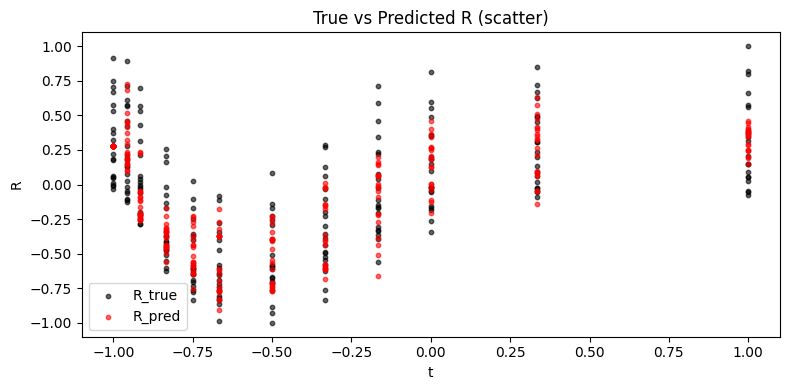

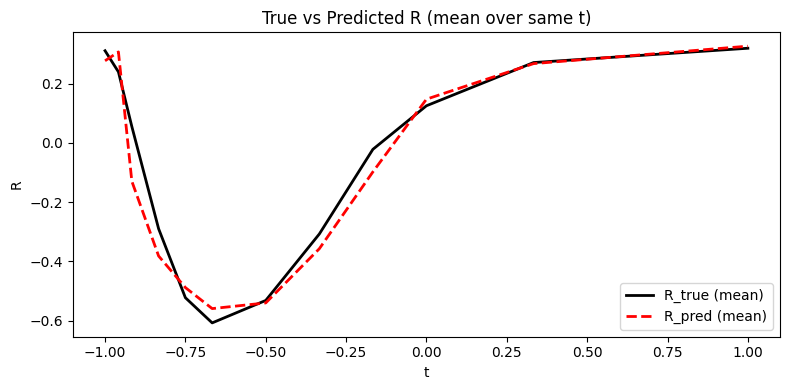

In [21]:
# ============================
# 8. 可视化：真实 vs 预测（修正版）
# ============================

import numpy as np
import torch
import matplotlib.pyplot as plt

model_stage2.eval()
with torch.no_grad():
    coords = dataset_pd.get_coords()    # [t, C]
    data = dataset_pd.get_data()        # R 真值
    pred, _ = model_stage2.func_approx(coords)

t = coords[:, 0].detach().cpu().numpy().flatten()
R_true = data[:, 0].detach().cpu().numpy().flatten()
R_pred = pred[:, 0].detach().cpu().numpy().flatten()

# ---- 方式 A：散点图（避免重复 t 的竖线）----
plt.figure(figsize=(8, 4))
plt.scatter(t, R_true, s=10, color="black", label="R_true", alpha=0.6)
plt.scatter(t, R_pred, s=10, color="red", label="R_pred", alpha=0.6)
plt.xlabel("t")
plt.ylabel("R")
plt.title("True vs Predicted R (scatter)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- 方式 B：按时间均值画曲线 ----
# 对重复 t 取均值
unique_t = np.unique(t)
R_true_mean = np.array([R_true[t == ut].mean() for ut in unique_t])
R_pred_mean = np.array([R_pred[t == ut].mean() for ut in unique_t])

plt.figure(figsize=(8, 4))
plt.plot(unique_t, R_true_mean, color="black", linewidth=2, label="R_true (mean)")
plt.plot(unique_t, R_pred_mean, color="red", linestyle="--", linewidth=2, label="R_pred (mean)")
plt.xlabel("t")
plt.ylabel("R")
plt.title("True vs Predicted R (mean over same t)")
plt.legend()
plt.tight_layout()
plt.show()

R²   = 0.7145
RMSE = 0.2385


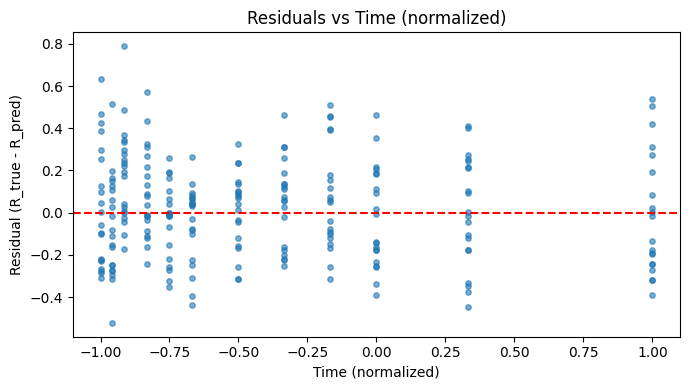

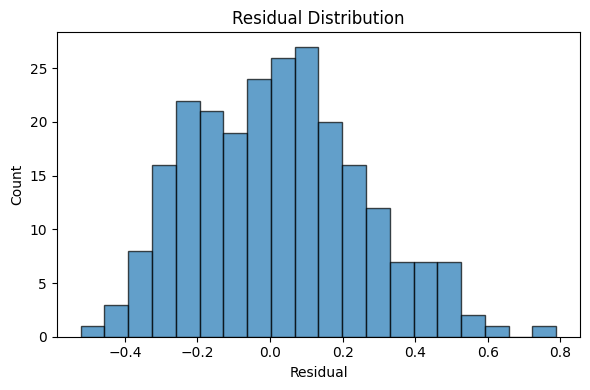

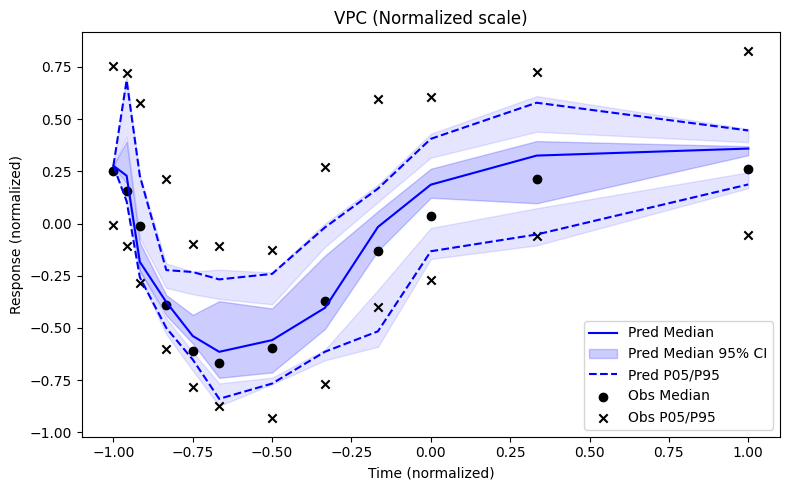

In [23]:
# ============================
# 9. 模型评估（修正版）：R² / RMSE / 残差 / VPC / Bootstrap
#    使用训练时同尺度的 dataset_pd
# ============================

import numpy as np
import torch
import matplotlib.pyplot as plt

# ---- 1) 预测（与训练一致的坐标/数据）----
model_stage2.eval()
with torch.no_grad():
    coords = dataset_pd.get_coords()  # 已归一化
    data = dataset_pd.get_data()      # 已归一化
    pred, _ = model_stage2.func_approx(coords)

R_pred = pred[:, 0].detach().cpu().numpy().flatten()
R_true = data[:, 0].detach().cpu().numpy().flatten()
t = coords[:, 0].detach().cpu().numpy().flatten()  # 归一化后的 t

# ---- 2) R² / RMSE ----
ss_res = np.sum((R_true - R_pred) ** 2)
ss_tot = np.sum((R_true - np.mean(R_true)) ** 2)
r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(np.mean((R_true - R_pred) ** 2))

print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.4f}")

# ---- 3) 残差图 ----
residuals = R_true - R_pred

plt.figure(figsize=(7, 4))
plt.scatter(t, residuals, s=15, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Time (normalized)")
plt.ylabel("Residual (R_true - R_pred)")
plt.title("Residuals vs Time (normalized)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, alpha=0.7, edgecolor="k")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

# ---- 4) VPC + Bootstrap（归一化时序）----
B = 300
np.random.seed(42)

n_subj = n_subjects
n_t = len(t_clinical)
subject_id = np.repeat(np.arange(n_subj), n_t)

unique_t = np.unique(t)

def quantiles_at_time(values, times, target_t, qs=[0.05, 0.5, 0.95]):
    vals = values[times == target_t]
    if len(vals) == 0:
        return [np.nan]*len(qs)
    return np.quantile(vals, qs)

# 观测分位数
obs_q = {q: [] for q in [0.05, 0.5, 0.95]}
pred_q = {q: [] for q in [0.05, 0.5, 0.95]}

for ut in unique_t:
    q_obs = quantiles_at_time(R_true, t, ut)
    q_pred = quantiles_at_time(R_pred, t, ut)
    for i, qv in enumerate([0.05, 0.5, 0.95]):
        obs_q[qv].append(q_obs[i])
        pred_q[qv].append(q_pred[i])

# Bootstrap：按受试者重采样
boot_q = {q: [] for q in [0.05, 0.5, 0.95]}

for b in range(B):
    samp_ids = np.random.choice(np.arange(n_subj), size=n_subj, replace=True)
    idx = np.isin(subject_id, samp_ids)

    t_b = t[idx]
    pred_b = R_pred[idx]

    q_b = {q: [] for q in [0.05, 0.5, 0.95]}
    for ut in unique_t:
        qvals = quantiles_at_time(pred_b, t_b, ut)
        for i, qv in enumerate([0.05, 0.5, 0.95]):
            q_b[qv].append(qvals[i])

    for qv in [0.05, 0.5, 0.95]:
        boot_q[qv].append(q_b[qv])

# 计算 bootstrap 置信带
boot_low = {}
boot_high = {}
for qv in [0.05, 0.5, 0.95]:
    arr = np.array(boot_q[qv])
    boot_low[qv] = np.nanpercentile(arr, 2.5, axis=0)
    boot_high[qv] = np.nanpercentile(arr, 97.5, axis=0)

# ---- 5) 绘制 VPC ----
plt.figure(figsize=(8, 5))

plt.plot(unique_t, pred_q[0.5], color="blue", label="Pred Median")
plt.fill_between(unique_t, boot_low[0.5], boot_high[0.5], color="blue", alpha=0.2, label="Pred Median 95% CI")

plt.plot(unique_t, pred_q[0.05], color="blue", linestyle="--", label="Pred P05/P95")
plt.plot(unique_t, pred_q[0.95], color="blue", linestyle="--")
plt.fill_between(unique_t, boot_low[0.05], boot_high[0.05], color="blue", alpha=0.1)
plt.fill_between(unique_t, boot_low[0.95], boot_high[0.95], color="blue", alpha=0.1)

plt.scatter(unique_t, obs_q[0.5], color="black", label="Obs Median")
plt.scatter(unique_t, obs_q[0.05], color="black", marker="x", label="Obs P05/P95")
plt.scatter(unique_t, obs_q[0.95], color="black", marker="x")

plt.xlabel("Time (normalized)")
plt.ylabel("Response (normalized)")
plt.title("VPC (Normalized scale)")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# ============================
# 10. 反归一化公式（基于 pop_data 的 min/max）
# ============================

import numpy as np

# 原始数据 min/max
t_min, t_max = pop_data[:, 0].min(), pop_data[:, 0].max()
C_min, C_max = pop_data[:, 1].min(), pop_data[:, 1].max()
R_min, R_max = pop_data[:, 2].min(), pop_data[:, 2].max()

# 归一化到 [-1, 1] 的尺度参数
a_t = (t_max - t_min) / 2.0
b_t = (t_max + t_min) / 2.0

a_C = (C_max - C_min) / 2.0
b_C = (C_max + C_min) / 2.0

a_R = (R_max - R_min) / 2.0
b_R = (R_max + R_min) / 2.0

print("a_t, b_t =", a_t, b_t)
print("a_C, b_C =", a_C, b_C)
print("a_R, b_R =", a_R, b_R)

# 模型系数（从 Stage-2 结果得出）
k1 = 5.8810     # R
k2 = 0.5391     # C
k3 = -0.0920    # sat(R)

# 归一化变量关系：
# Rn = (R - b_R)/a_R
# Cn = (C - b_C)/a_C
# tn = (t - b_t)/a_t

print("\n[反归一化公式]")
print("dR/dt = (a_R/a_t) * [ k1*Rn + k2*Cn + k3*sat(Rn) ]")
print("Rn = (R - b_R)/a_R,   Cn = (C - b_C)/a_C")
print(model_stage2.library.k_sat_R)

a_t, b_t = 12.0 12.0
a_C, b_C = 4.142102746883953 4.142102746883953
a_R, b_R = 35.40341420012337 40.733936043866144

[反归一化公式]
dR/dt = (a_R/a_t) * [ k1*Rn + k2*Cn + k3*sat(Rn) ]
Rn = (R - b_R)/a_R,   Cn = (C - b_C)/a_C
Parameter containing:
tensor(0.7662, device='cuda:0', requires_grad=True)
